
1️⃣ Load Dataset


In [1]:

import pandas as pd

df = pd.read_csv("train.csv")   # Kaggle Titanic train.csv
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



2️⃣ Handle Missing Values (Basic)


In [2]:

# # Fill Age with median
# df['Age'].fillna(df['Age'].median(), inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].median())

# # Fill Embarked with mode
# df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



3️⃣ Feature Engineering

🔹 Label Encoding (Ordinal / Binary)  
Encode Sex (Male/Female)


In [3]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

df[['Sex']].head()
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,C



Sex	Encoded  
male	1  
female	0



🔹 One-Hot Encoding (Nominal)  
Encode Embarked


In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,C


In [5]:
df
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,False,True



New columns:

- Embarked_Q  
- Embarked_S



4️⃣ Feature Selection

🔹 Correlation-Based Feature Selection


In [6]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()


ValueError: could not convert string to float: 'Braund, Mr. Owen Harris'

<Figure size 1000x600 with 0 Axes>

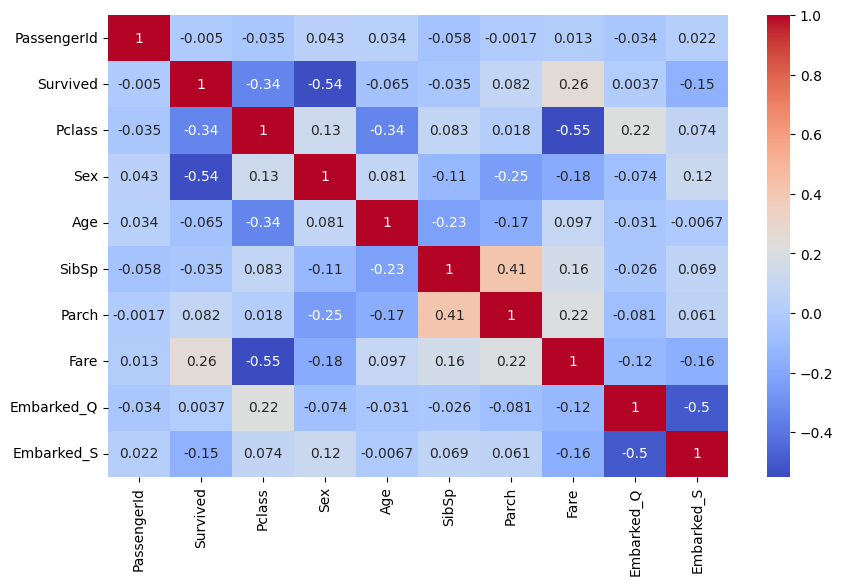

In [7]:
df_corr = df.drop(['Name', 'Ticket', 'Cabin'], axis=1)

plt.figure(figsize=(10,6))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm")
plt.show()



🔍 Observation

Features strongly correlated with Survived:

- Sex  
- Fare  
- Pclass  

Weak / redundant features can be dropped.



🔹 SelectKBest (Statistical Feature Selection)


In [8]:

from sklearn.feature_selection import SelectKBest, f_classif

X = df.drop(['Survived', 'Name', 'Ticket', 'Cabin'], axis=1)
y = df['Survived']

selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print(selected_features)
X_selected


Index(['Pclass', 'Sex', 'Parch', 'Fare', 'Embarked_S'], dtype='object')


array([[ 3.    ,  1.    ,  0.    ,  7.25  ,  1.    ],
       [ 1.    ,  0.    ,  0.    , 71.2833,  0.    ],
       [ 3.    ,  0.    ,  0.    ,  7.925 ,  1.    ],
       ...,
       [ 3.    ,  0.    ,  2.    , 23.45  ,  1.    ],
       [ 1.    ,  1.    ,  0.    , 30.    ,  0.    ],
       [ 3.    ,  1.    ,  0.    ,  7.75  ,  0.    ]])


✅ Output (example):

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked_S'], dtype='object')



5️⃣ Train–Test Split


In [19]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features],
    y,
    test_size=0.2,
    random_state=42
)

X_test.head()


,Pclass,Sex,Parch,Fare,Embarked_S
709,3,1,1,15.2458,False
439,2,1,0,10.5000,True
840,3,1,0,7.9250,True
720,2,0,1,33.0000,True
39,3,0,0,11.2417,False



✔ 80% Training  
✔ 20% Testing  
✔ random_state ensures reproducibility


**Standardization and Normalization**

---



In [20]:
import pandas as pd

# Create a simple dataset
data = {
    'Age': [18, 22, 25, 30, 35, 40],
    'Salary': [15000, 20000, 25000, 40000, 60000, 80000]
}

df = pd.DataFrame(data)
df


,Age,Salary
0,18,15000
1,22,20000
2,25,25000
3,30,40000
4,35,60000
5,40,80000


Step 2: Train–Test Split

In [21]:
from sklearn.model_selection import train_test_split

X = df[['Age', 'Salary']]

X_train, X_test = train_test_split(
    X,
    test_size=0.3,random_state=42

)

X_train, X_test


(   Age  Salary
 5   40   80000
 2   25   25000
 4   35   60000
 3   30   40000,
    Age  Salary
 0   18   15000
 1   22   20000)

Data is split
✔ random_state ensures reproducibility

**Feature Scaling**

**🔹 Standardization (Z-Score Scaling)**

In [22]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

X_train_std, X_test_std


(array([[ 1.34164079,  1.38695219],
        [-1.34164079, -1.26634765],
        [ 0.4472136 ,  0.42211588],
        [-0.4472136 , -0.54272042]]),
 array([[-2.59383885, -1.7487658 ],
        [-1.8782971 , -1.50755672]]))

📌 What happens?

Mean → 0

Standard Deviation → 1

Values can be negative or positive

📌 Used for:

Logistic Regression

SVM

PCA

**Normalization (Min-Max Scaling)**

In [23]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

X_train_norm = minmax_scaler.fit_transform(X_train)
X_test_norm = minmax_scaler.transform(X_test)

X_train_norm, X_test_norm


(array([[1.        , 1.        ],
        [0.        , 0.        ],
        [0.66666667, 0.63636364],
        [0.33333333, 0.27272727]]),
 array([[-0.46666667, -0.18181818],
        [-0.2       , -0.09090909]]))

📌 What happens?

Minimum value → 0

Maximum value → 1

All values lie between 0 and 1

📌 Used for:

KNN

K-Means

Neural Networks